In [8]:
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

sys.path.append('C:/dev/project/SKN27-2nd-4TEAM')

from src.seed import set_seed                                              # ← 추가
from src.pipeline.missing_value import CJ_MissingValue, JH_train_stats, JH_MissingValue
from src.pipeline.outlier_control import OutlierControl
from src.pipeline.features import FeatureCreate

# 시드 고정
set_seed(42)  # ← 추가

In [9]:
# ── 1. 데이터 로드 ──────────────────────────────
df = pd.read_excel('C:/dev/project/SKN27-2nd-4TEAM/data/dataset.xlsx', sheet_name='E Comm')
df = df.drop(columns=['CustomerID'])  # ID 컬럼 제거

# ── 2. Train/Test 분리 ──────────────────────────
X = df.drop(columns=['Churn'])
y = df['Churn']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_tr: {X_tr.shape}, X_te: {X_te.shape}")
print(f"Train churn 비율: {y_tr.mean():.3f}")
print(f"Test  churn 비율: {y_te.mean():.3f}")

X_tr: (4504, 18), X_te: (1126, 18)
Train churn 비율: 0.168
Test  churn 비율: 0.169


In [10]:
# ── 3. 결측치 제거 (missing_value.py 사용) ───────

# CJ 방식: 그룹별 중앙값으로 채우기
cj_cols = {
    'Tenure':                    ('NumberOfAddress', 5),
    'DaySinceLastOrder':         (['PreferedOrderCat', 'PreferredLoginDevice'], 10),
    'OrderCount':                (['PreferedOrderCat', 'PreferredPaymentMode'], 10),
    'OrderAmountHikeFromlastYear': ('PreferedOrderCat', 3),
}

for col, (group_cols, min_size) in cj_cols.items():
    train_median = X_tr[col].median()
    X_tr = CJ_MissingValue(X_tr, col, group_cols, min_size, train_median)
    X_te = CJ_MissingValue(X_te, col, group_cols, min_size, train_median, test_df=None)
    X_te[col] = X_te[col].fillna(train_median)  # test 잔여 결측치

# JH 방식: HourSpendOnApp, WarehouseToHome, CouponUsed
stats = JH_train_stats(X_tr)
X_tr = JH_MissingValue(X_tr, **stats)
X_te = JH_MissingValue(X_te, **stats)

print("결측치 확인:")
print(X_tr.isnull().sum()[X_tr.isnull().sum() > 0])
print(X_te.isnull().sum()[X_te.isnull().sum() > 0])

결측치 확인:
Series([], dtype: int64)
Series([], dtype: int64)


In [11]:
X_te.isnull().sum()

Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [12]:
# ── 4. 이상치 제거 (outlier_control.py 사용) ─────
cols = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'CashbackAmount']

X_tr = OutlierControl(X_tr, cols)
X_te = OutlierControl(X_te, cols)

print("이상치 처리 후 컬럼:")
print(X_tr.columns.tolist())

이상치 처리 후 컬럼:
['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'Tenure_log', 'WarehouseToHome_log', 'DaySinceLastOrder_clip', 'CashbackAmount_clip']


In [13]:
# ── 5. 피처 생성 (features.py 사용) ─────────────

# train 기준 월평균 주문 빈도 계산 (test에도 동일 기준 적용)
train_monthly_freq_mean = (
    X_tr['OrderCount'] / np.expm1(X_tr['Tenure_log']).clip(lower=0.1)
).mean()

X_tr = FeatureCreate(X_tr, train_monthly_freq_mean=train_monthly_freq_mean)
X_te = FeatureCreate(X_te, train_monthly_freq_mean=train_monthly_freq_mean)

print(f"최종 피처 수: {X_tr.shape[1]}")
print(X_tr.columns.tolist())

최종 피처 수: 25
['CityTier', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'Tenure_log', 'Dormancy_Shock', 'Recency_Tenure_Ratio', 'MonthlyOrderFreq', 'IssueIndex', 'Satisfaction_Per_Order', 'Silent_Killer', 'CashbackPerOrder', 'Promo_Sensitivity', 'Stagnant_Loyal', 'ManyAddressesFlag', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'MaritalStatus_Single', 'Gender_Male']


In [15]:
X_tr.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4504 entries, 1787 to 5140
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CityTier                             4504 non-null   int64  
 1   NumberOfDeviceRegistered             4504 non-null   int64  
 2   NumberOfAddress                      4504 non-null   int64  
 3   OrderAmountHikeFromlastYear          4504 non-null   float64
 4   Tenure_log                           4504 non-null   float64
 5   Dormancy_Shock                       4504 non-null   float64
 6   Recency_Tenure_Ratio                 4504 non-null   float64
 7   MonthlyOrderFreq                     4504 non-null   float64
 8   IssueIndex                           4504 non-null   int64  
 9   Satisfaction_Per_Order               4504 non-null   float64
 10  Silent_Killer                        4504 non-null   int64  
 11  CashbackPerOrder                

In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

In [17]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    # Score
    score_tr  = model.score(X_tr, y_tr)
    score_te  = model.score(X_te, y_te)
    diff      = score_tr - score_te

    # AUC
    train_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    test_auc  = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

    print(f'[{model_name}]')
    print(f'  학습 score : {score_tr:.4f}')
    print(f'  검증 score : {score_te:.4f}')
    print(f'  score 차이 : {diff:.4f} →', end=' ')
    print('⚠️ 과적합' if diff > 0.05 else '✅ 양호')
    print(f'  Train AUC  : {train_auc:.4f}')
    print(f'  Test  AUC  : {test_auc:.4f}')
    print()
    return test_auc


In [18]:

# ── 1단계: 기본 모델 ──────────────────────────
set_seed(42)
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    eval_metric='logloss'
)
xgb_base.fit(X_tr, y_tr)
auc_base = evaluate_model(xgb_base, X_tr, y_tr, X_te, y_te, '1단계: 기본 모델')


[1단계: 기본 모델]
  학습 score : 0.9967
  검증 score : 0.9609
  score 차이 : 0.0357 → ✅ 양호
  Train AUC  : 0.9999
  Test  AUC  : 0.9935



In [19]:
# ── 2단계: Imbalanced 보정 ───────────────────
neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
spw = neg / pos
print(f"scale_pos_weight: {spw:.2f}")

set_seed(42)
xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    eval_metric='logloss',
    scale_pos_weight=spw
)
xgb_balanced.fit(X_tr, y_tr)
auc_balanced = evaluate_model(xgb_balanced, X_tr, y_tr, X_te, y_te, '2단계: Imbalanced 보정')

scale_pos_weight: 4.94
[2단계: Imbalanced 보정]
  학습 score : 0.9938
  검증 score : 0.9654
  score 차이 : 0.0284 → ✅ 양호
  Train AUC  : 0.9999
  Test  AUC  : 0.9936



In [20]:
# ── 3단계: Overfitting 방지 ──────────────────
set_seed(42)
xgb_reg = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    eval_metric='logloss'
)
xgb_reg.fit(X_tr, y_tr)
auc_reg = evaluate_model(xgb_reg, X_tr, y_tr, X_te, y_te, '3단계: Overfitting 방지')

[3단계: Overfitting 방지]
  학습 score : 0.9247
  검증 score : 0.8943
  score 차이 : 0.0304 → ✅ 양호
  Train AUC  : 0.9804
  Test  AUC  : 0.9575



In [21]:
# ── 4단계: Cross Validation ──────────────────
set_seed(42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_reg, X_tr, y_tr, cv=cv, scoring='roc_auc')

print('[4단계: Cross Validation]')
print(f'  CV AUC scores : {cv_scores}')
print(f'  평균 AUC      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()

[4단계: Cross Validation]
  CV AUC scores : [0.96721413 0.95379805 0.93742534 0.9467887  0.94063608]
  평균 AUC      : 0.9492 ± 0.0106



In [22]:
# ── 최종 비교 ────────────────────────────────
print("=== 최종 비교 ===")
print("| 단계 | Test AUC |")
print("|---|---|")
print(f"| 1단계: 기본 모델         | {auc_base:.4f} |")
print(f"| 2단계: Imbalanced 보정  | {auc_balanced:.4f} |")
print(f"| 3단계: Overfitting 방지 | {auc_reg:.4f} |")
print(f"| 4단계: CV 평균          | {cv_scores.mean():.4f} |")

=== 최종 비교 ===
| 단계 | Test AUC |
|---|---|
| 1단계: 기본 모델         | 0.9935 |
| 2단계: Imbalanced 보정  | 0.9936 |
| 3단계: Overfitting 방지 | 0.9575 |
| 4단계: CV 평균          | 0.9492 |


In [ ]:
# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

set_seed(42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

xgb_tuned = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_tuned,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tr, y_tr)

print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최적 CV AUC: {grid_search.best_score_:.4f}")

# 최적 모델로 평가
best_model = grid_search.best_estimator_
auc_tuned = evaluate_model(best_model, X_tr, y_tr, X_te, y_te, '5단계: 튜닝 모델')


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
최적 파라미터: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.9}
최적 CV AUC: 0.9635
[5단계: 튜닝 모델]
  학습 score : 0.9964
  검증 score : 0.9707
  score 차이 : 0.0258 → ✅ 양호
  Train AUC  : 0.9999
  Test  AUC  : 0.9952



In [24]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

def evaluate_full(model, X_te, y_te, model_name='Model'):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    print(f'[{model_name}]')
    print(f'  AUC       : {roc_auc_score(y_te, y_proba):.4f}')
    print(f'  Accuracy  : {model.score(X_te, y_te):.4f}')
    print(f'  Precision : {precision_score(y_te, y_pred):.4f}')  # 이탈 예측 중 실제 이탈
    print(f'  Recall    : {recall_score(y_te, y_pred):.4f}')     # 실제 이탈 중 맞춘 비율
    print(f'  F1 Score  : {f1_score(y_te, y_pred):.4f}')        # Precision+Recall 조화평균
    print()
    print(classification_report(y_te, y_pred, target_names=['정상', '이탈']))

In [27]:
evaluate_full(best_model, X_te, y_te, '최종 모델 상세 평가')

[최종 모델 상세 평가]
  AUC       : 0.9952
  Accuracy  : 0.9707
  Precision : 0.8792
  Recall    : 0.9579
  F1 Score  : 0.9169

              precision    recall  f1-score   support

          정상       0.99      0.97      0.98       936
          이탈       0.88      0.96      0.92       190

    accuracy                           0.97      1126
   macro avg       0.94      0.97      0.95      1126
weighted avg       0.97      0.97      0.97      1126



c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 53448 (\N{HANGUL SYLLABLE TAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPytho

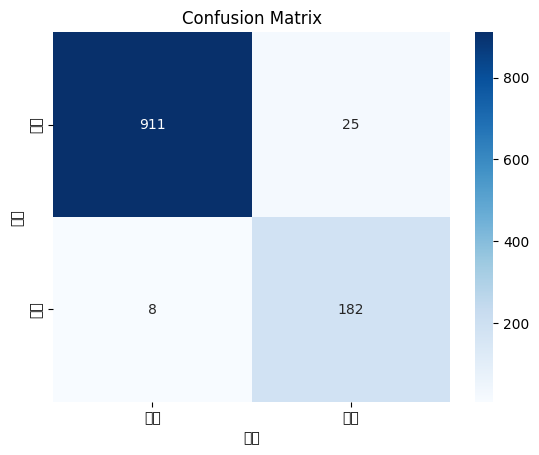

In [28]:
# 혼동 행렬
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te, best_model.predict(X_te))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상', '이탈'],
            yticklabels=['정상', '이탈'])
plt.xlabel('예측')
plt.ylabel('실제')
plt.title('Confusion Matrix')
plt.show()

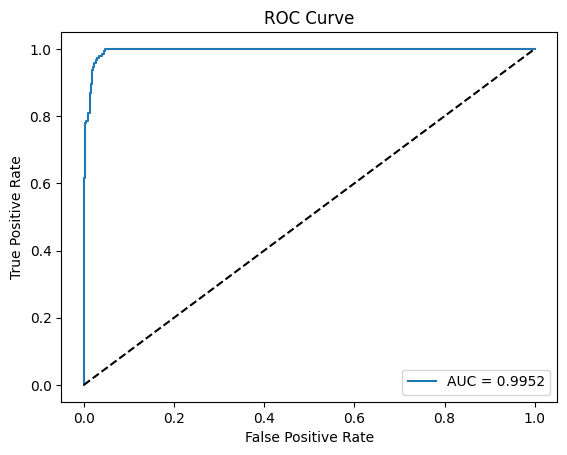

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_te, best_model.predict_proba(X_te)[:, 1])

plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_te, best_model.predict_proba(X_te)[:,1]):.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing 

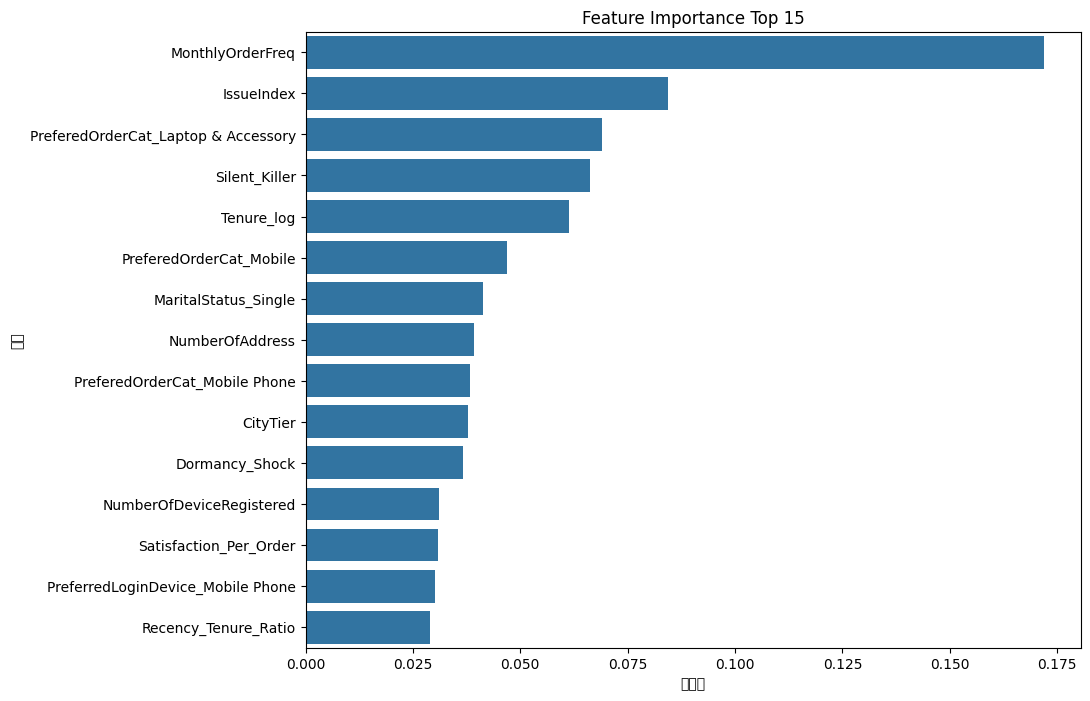

In [30]:
import pandas as pd

feature_importance = pd.DataFrame({
    '피처': X_tr.columns,
    '중요도': best_model.feature_importances_
}).sort_values('중요도', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='중요도', y='피처')
plt.title('Feature Importance Top 15')
plt.show()